# 1. Problem Definition
-

# 2. Import and Data Overview
-

In [28]:
# Import packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

In [29]:
# Import data
df = pd.read_csv("C:\\Users\\ajdpe\\Desktop\\Ficheiros\\4. PYTHON\\car-price-regression\\data\\train.csv")
display(df.head())
print(df.columns)
print(df.info())
print(df.describe())

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4


Index(['ID', 'Price', 'Levy', 'Manufacturer', 'Model', 'Prod. year',
       'Category', 'Leather interior', 'Fuel type', 'Engine volume', 'Mileage',
       'Cylinders', 'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color',
       'Airbags'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  str    
 3   Manufacturer      19237 non-null  str    
 4   Model             19237 non-null  str    
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  str    
 7   Leather interior  19237 non-null  str    
 8   Fuel type         19237 non-null  str    
 9   Engine volume     19237 non-null  str    
 10  Mileage           19237 non-null  str    
 11  Cylinders         1

In [30]:
# Check for value features:
for col in df.columns:
    print(f"Column: {col}")
    print(df[col].value_counts())
    print("\n")

Column: ID
ID
45815361    8
45815365    8
45815363    7
45815368    7
45723475    7
           ..
45798355    1
45778856    1
45804997    1
45793526    1
45813273    1
Name: count, Length: 18924, dtype: int64


Column: Price
Price
15681    280
470      274
14113    244
392      242
314      235
        ... 
17042      1
18779      1
56814      1
63886      1
22075      1
Name: count, Length: 2315, dtype: int64


Column: Levy
Levy
-       5819
765      486
891      461
639      410
640      405
        ... 
2308       1
4860       1
1641       1
1045       1
1901       1
Name: count, Length: 559, dtype: int64


Column: Manufacturer
Manufacturer
HYUNDAI          3769
TOYOTA           3662
MERCEDES-BENZ    2076
FORD             1111
CHEVROLET        1069
                 ... 
LAMBORGHINI         1
PONTIAC             1
SATURN              1
ASTON MARTIN        1
GREATWALL           1
Name: count, Length: 65, dtype: int64


Column: Model
Model
Prius                       1083
Sonata       

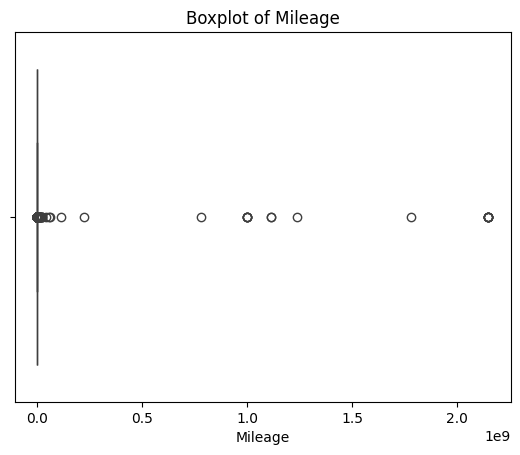

In [31]:
# Check Outliers of Mileage

# Turn Mileage into numerical
df['Mileage'] = df['Mileage'].str.replace(' km', '').astype(int)
# Visualize the distribution of Mileage
sns.boxplot(x=df["Mileage"])
plt.title("Boxplot of Mileage")
plt.show()

# Check -> print(df.sort_values(by='Mileage', ascending=False).head(10))

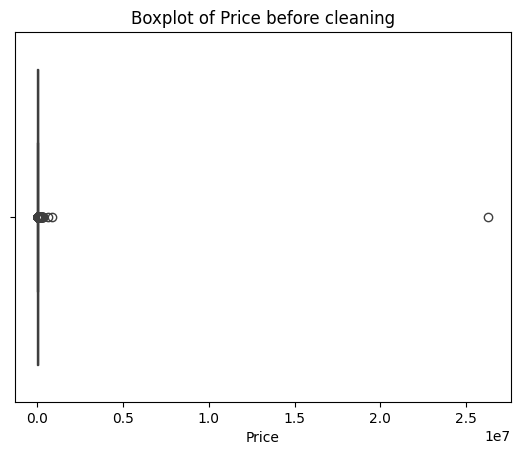

             ID     Price  Levy   Manufacturer                    Model  \
16983  45812886  26307500     -           OPEL                    Combo   
8541   45761204    872946  2067    LAMBORGHINI                     Urus   
1225   45795524    627220     -  MERCEDES-BENZ           G 65 AMG 63AMG   
5008   45810285    308906  1694        PORSCHE                      911   
9367   45229113    297930     -  MERCEDES-BENZ                 AMG GT S   
14839  45792307    297930     -     LAND ROVER        Range Rover Vogue   
7749   45760644    288521  2269            BMW  M5 Машина в максимально   
10759  45291161    260296     -          LEXUS                   LX 570   
5840   44991441    254024  1292  MERCEDES-BENZ            GLE 400 A M G   
15283  45069516    250574  1481  MERCEDES-BENZ                  GLE 400   

       Prod. year     Category Leather interior Fuel type Engine volume  \
16983        1999  Goods wagon               No    Diesel           1.7   
8541         2019    Uni

In [32]:
# Check Outliers of Target Variable and distribution

#Visualize the distribution of Price
sns.boxplot(x=df["Price"])
plt.title("Boxplot of Price before cleaning")   
plt.show()

#Top 10 most expensive cars
print(df.sort_values(by='Price', ascending=False).head(10))

#Top 10 least expensive cars
print(df.sort_values(by='Price', ascending=True).head(10))


## Conclusions

- The original dataset contains 19,237 rows and 18 columns, with a mix of numerical and categorical features. 

### Missing Data
- The 'Levy' column contains missing or invalid values represented as '-', which will require cleaning.

### Data Types
- Some features are stored as strings but represent numerical values:
- 'Mileage' and 'Doors' should be converted to integer.
- 'Engine volume' should be converted to float.

### Data Quality Observations
- Target variable 'Price' was checked for distribution and outliers. The most expensive car is an OPEL (>26M) which will be deemed a mistake. There are as well several cars with prices of 1, 3, etc, so values below a certain threshold will be eliminated from the dataframe.
- 'Mileage' has several observations with millions of miles, which are likely mistakes and need to be excluded.
- 'Mileage' includes units ('km') and will require cleaning. 
- 'Doors' contains inconsistent formatting (e.g. '02-Mar', '04-May'), requiring standardization.
- Some categorical features appear to have limited categories (e.g. 'Wheel', 'Leather Interior').

### Initial Observations
- Target variable 'Price' is right-skewed, will need to be transformed.:
- Might make sense to transform date of production, which is a year, into a 'years since productions', subtracting the date of production to the current year.
- 'Mileage' has 'km', which needs to be cleaned.
- 'Doors' has a 2 and 4 door incorrectely typed, which needs to be transformed.
- Categorical features with only two categories such as 'Wheel' and 'Leather Interior' might be transformed into binary.
- Might be interesting to create a new feature 'Turbo' for when the 'Engine Volume' feature has 'Turbo' in it, as well as create intervals for the 'Engine Volume'. It might be interesting as well as for 'Fuel Type' to reduce categories.

# 3. Data Cleaning

In [33]:
# Start be cleaning the target variable 'Price'

# Exclude most expensive car (OPEL, mistake)
df = df[df['Price'] != df['Price'].max()]

# Exclude cars below 2000 euros (probably mistakes)
df = df[df['Price'] >= 2000]

# Transform 'Mileage' to numeric and exclude extreme values that are mistakes
quantile_99_mileage = df['Mileage'].quantile(0.99)
df = df[df['Mileage'] <= quantile_99_mileage]

# Check out many rows were eliminated
print(f"Number of rows after cleaning: {len(df)} (vs. 19237 before cleaning)")

Number of rows after cleaning: 15873 (vs. 19237 before cleaning)


In [34]:
# Substitute '-' with 0 in the levy variable and turn it into numeric
df['Levy'] = df['Levy'].replace('-', '0').astype(float)

# Correct 'Doors' variable
df['Doors'] = df['Doors'].replace('04-May', '4')
df['Doors'] = df['Doors'].replace('02-Mar', '2')
print(df['Doors'].value_counts())

# Drop from model column 'ID' (not useful for prediction)
df = df.drop(columns=['ID'])

Doors
4     15042
2       716
>5      115
Name: count, dtype: int64


In [35]:
# Check data after cleaning
display(df.head())
print(df.info())

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,13328,1399.0,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005,6.0,Automatic,4x4,4,Left wheel,Silver,12
1,16621,1018.0,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000,6.0,Tiptronic,4x4,4,Left wheel,Black,8
2,8467,0.0,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000,4.0,Variator,Front,4,Right-hand drive,Black,2
3,3607,862.0,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966,4.0,Automatic,4x4,4,Left wheel,White,0
4,11726,446.0,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901,4.0,Automatic,Front,4,Left wheel,Silver,4


<class 'pandas.DataFrame'>
Index: 15873 entries, 0 to 19235
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             15873 non-null  int64  
 1   Levy              15873 non-null  float64
 2   Manufacturer      15873 non-null  str    
 3   Model             15873 non-null  str    
 4   Prod. year        15873 non-null  int64  
 5   Category          15873 non-null  str    
 6   Leather interior  15873 non-null  str    
 7   Fuel type         15873 non-null  str    
 8   Engine volume     15873 non-null  str    
 9   Mileage           15873 non-null  int64  
 10  Cylinders         15873 non-null  float64
 11  Gear box type     15873 non-null  str    
 12  Drive wheels      15873 non-null  str    
 13  Doors             15873 non-null  str    
 14  Wheel             15873 non-null  str    
 15  Color             15873 non-null  str    
 16  Airbags           15873 non-null  int64  
dtypes: float6

## Conclusions
- Exclude the most expensive car (mistake)
- Exclude group of cars below 2000, highly likely they're mistakes (foram eliminados 3364)
- Clean mileage and transform into numeric
- Clean levy column and turn into numeric
- Clean doors feature
- Drop 'id'

# EDA

## Univariate Analysis

In [36]:
# Separate numerical and categorical variables
print(df.columns)
numerical_cols = ['Mileage', 'Price', 'Levy']
categorical_cols = ['Cylinders', 'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color', 'Airbags', 'Leather interior', 'Fuel type', 'Engine volume','Manufacturer', 'Model', 'Prod. year', 'Category']


Index(['Price', 'Levy', 'Manufacturer', 'Model', 'Prod. year', 'Category',
       'Leather interior', 'Fuel type', 'Engine volume', 'Mileage',
       'Cylinders', 'Gear box type', 'Drive wheels', 'Doors', 'Wheel', 'Color',
       'Airbags'],
      dtype='str')


## Bivariate Analysis

Correlation between Mileage and Price: -0.20022374037613236


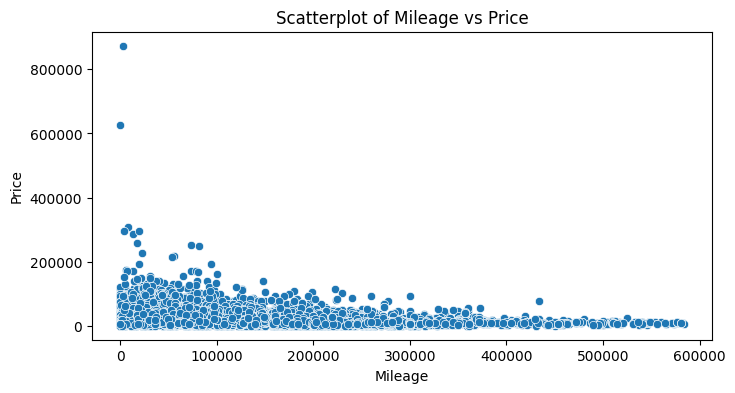

Correlation between Levy and Price: 0.1237145178846382


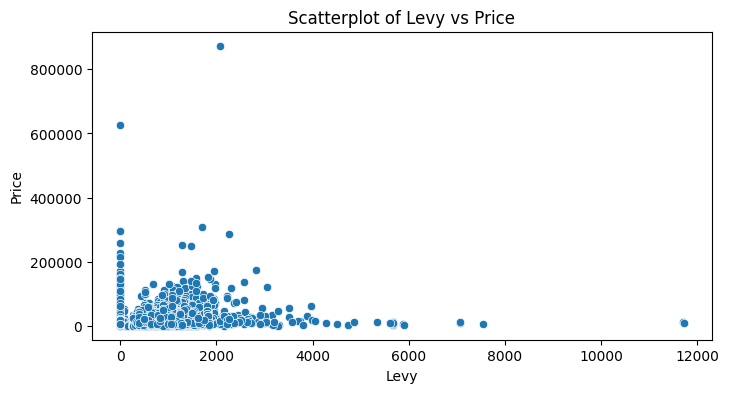

In [37]:
# Visualize relationship between numerical variables and target variable 'Price'
for col in numerical_cols:
    if col != 'Price':
        print(f"Correlation between {col} and Price: {df['Price'].corr(df[col])}")
        plt.figure(figsize=(8, 4))
        sns.scatterplot(x=df[col], y=df['Price'])
        plt.title(f"Scatterplot of {col} vs Price")
        plt.xlabel(col)
        plt.ylabel("Price")
        plt.show()

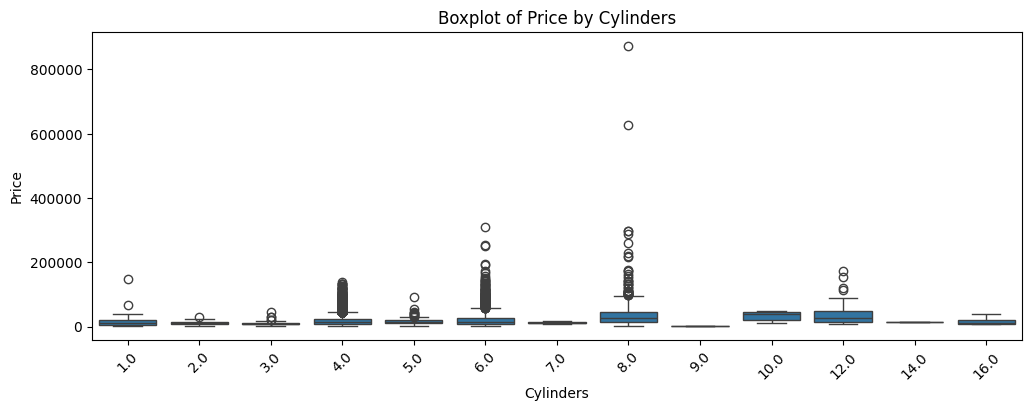

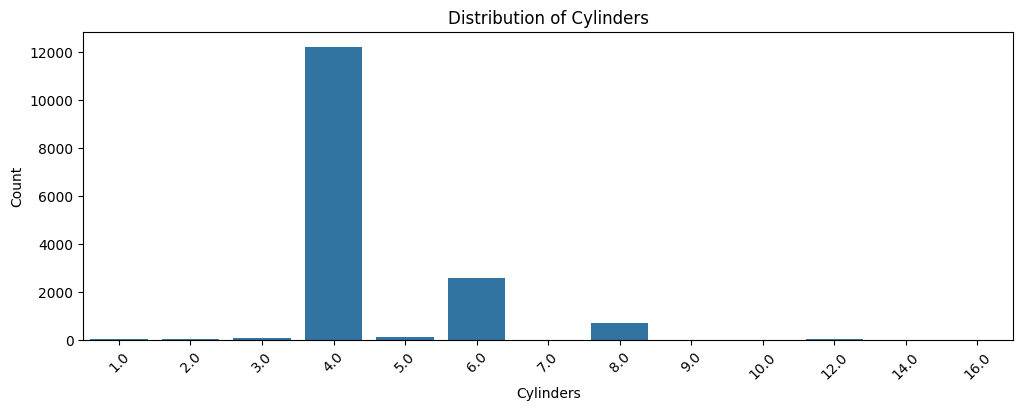

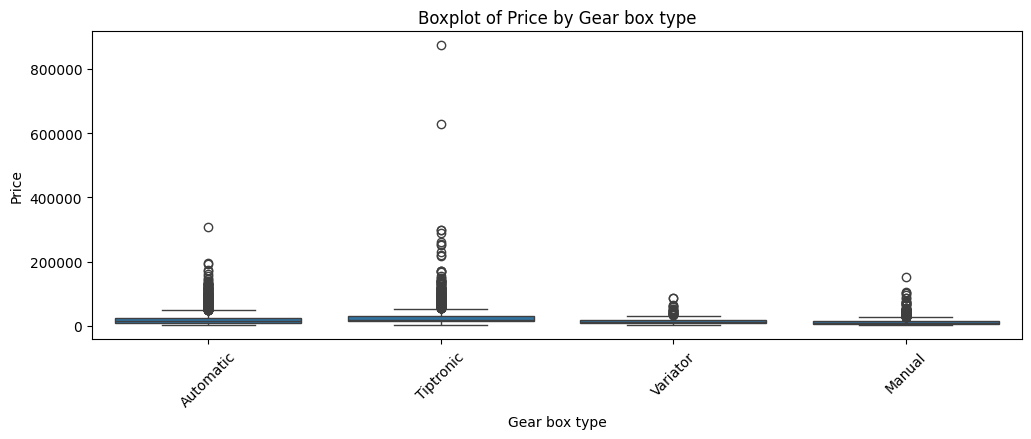

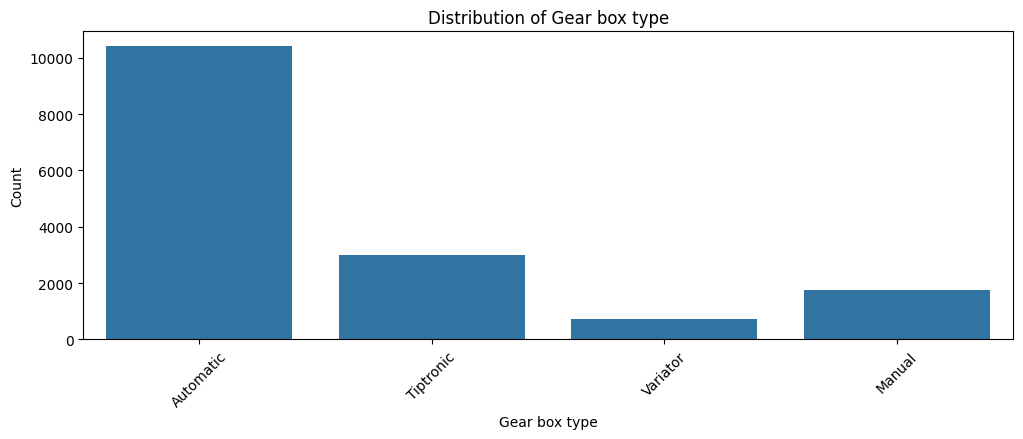

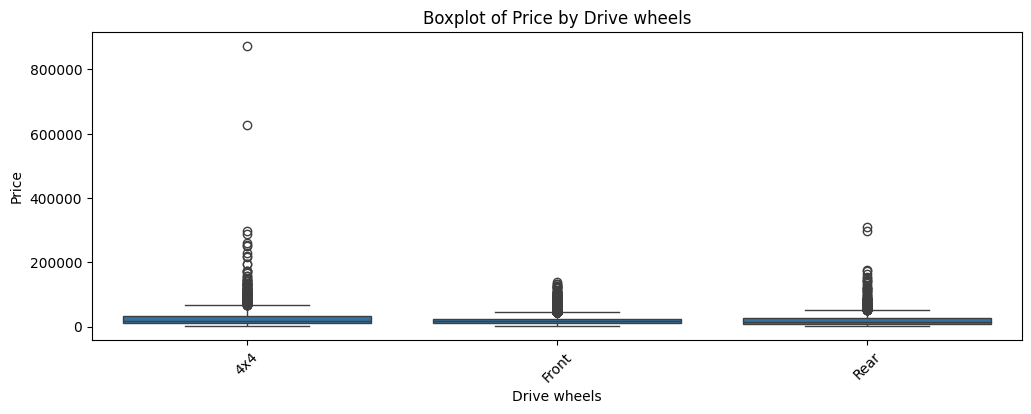

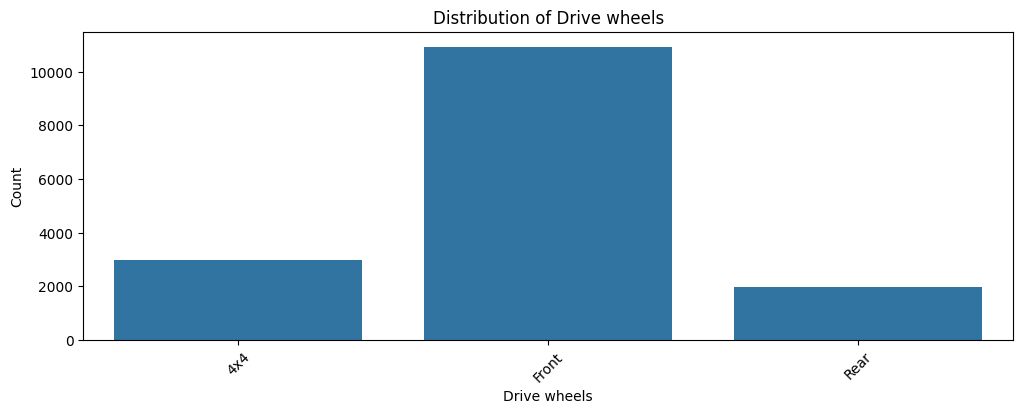

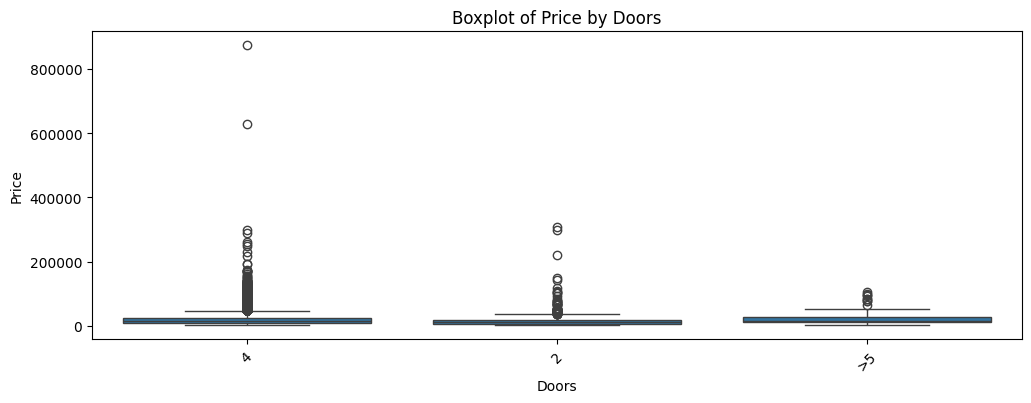

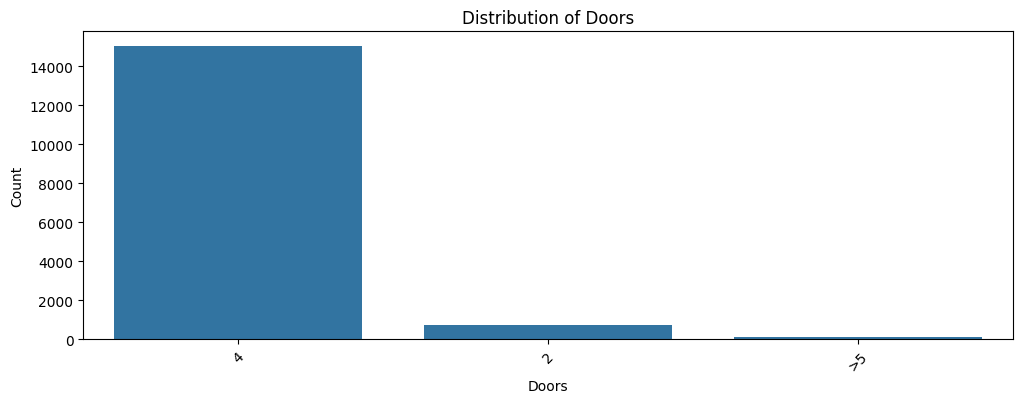

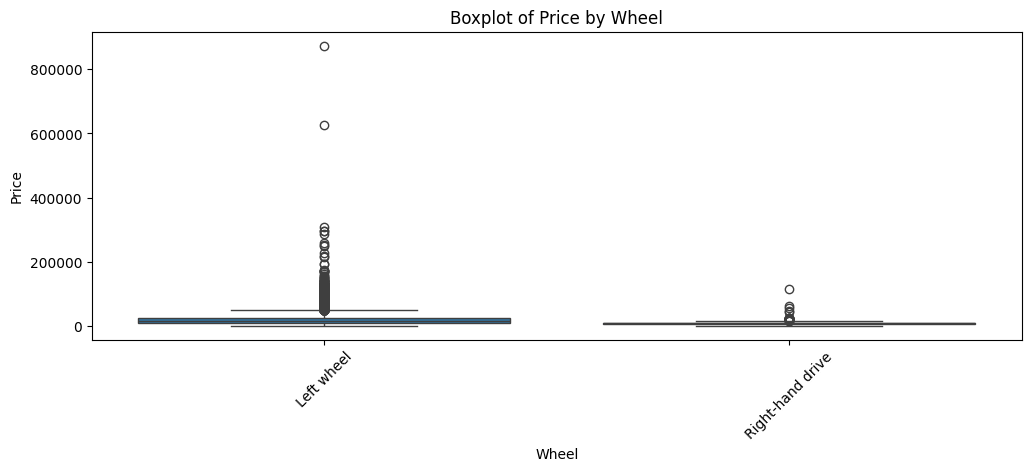

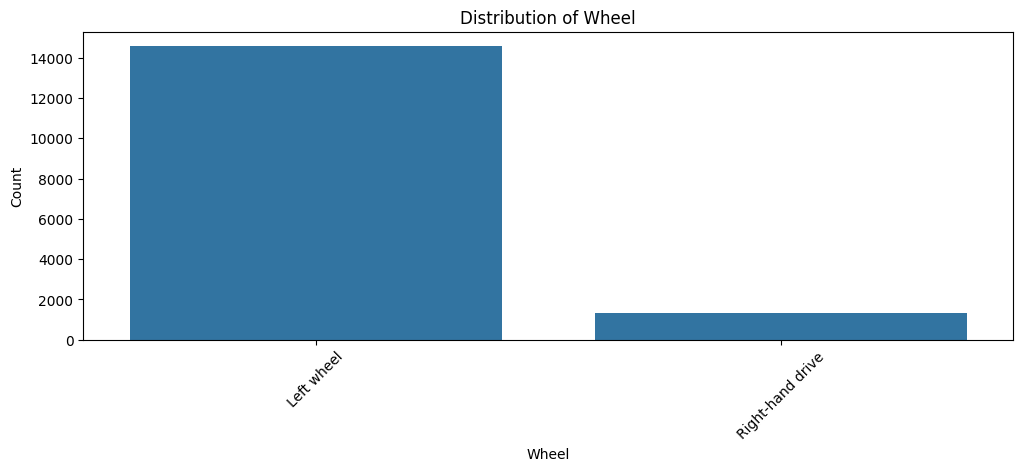

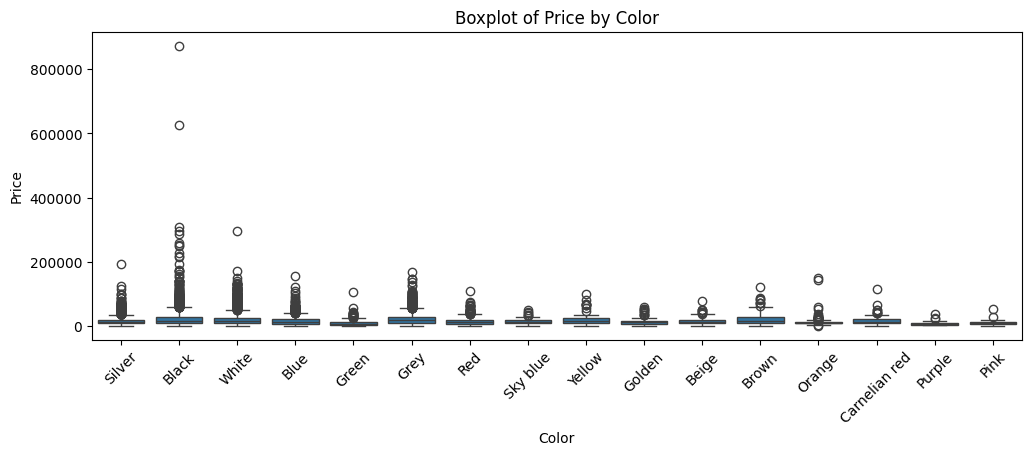

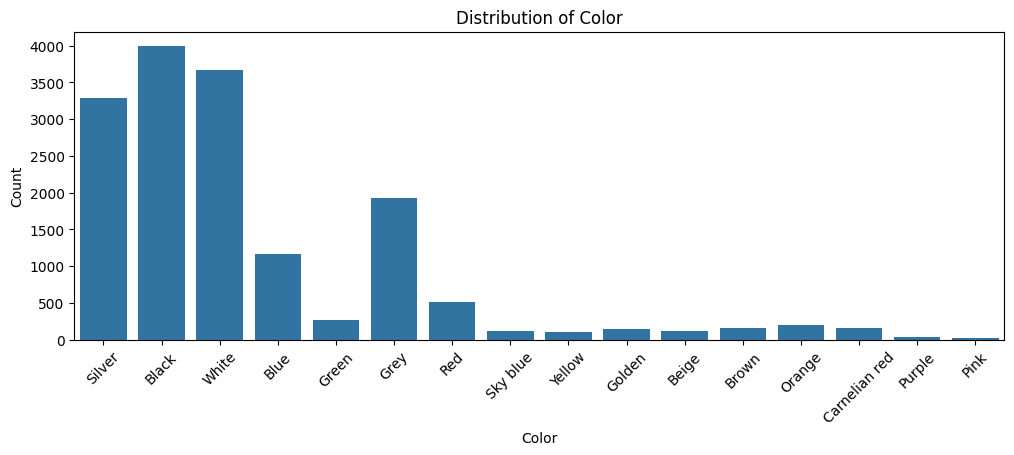

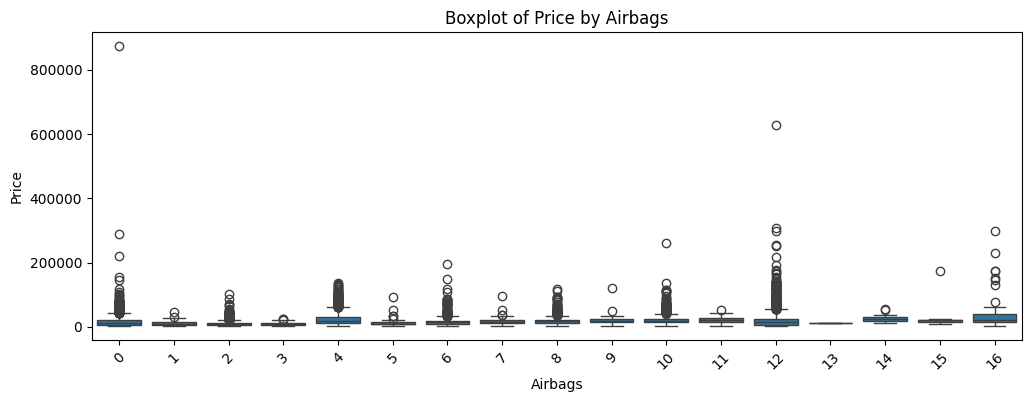

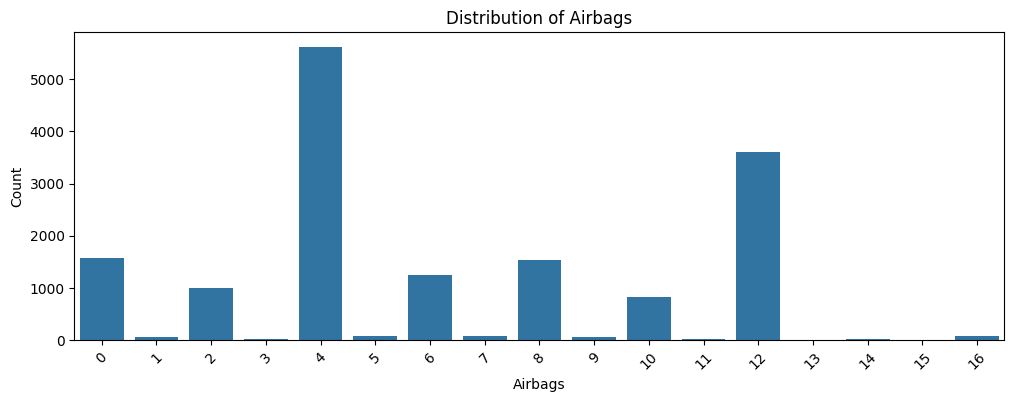

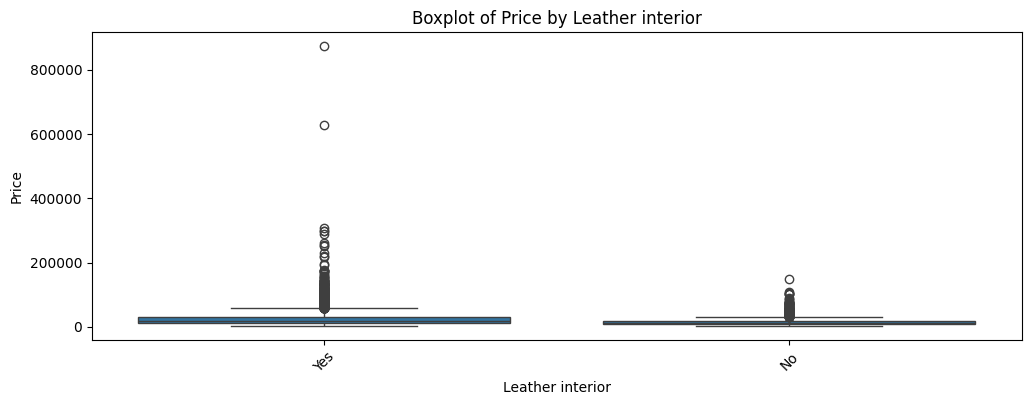

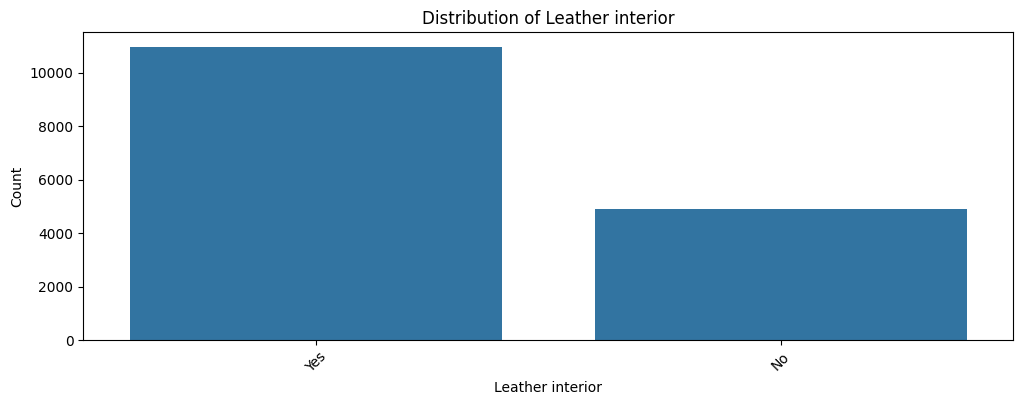

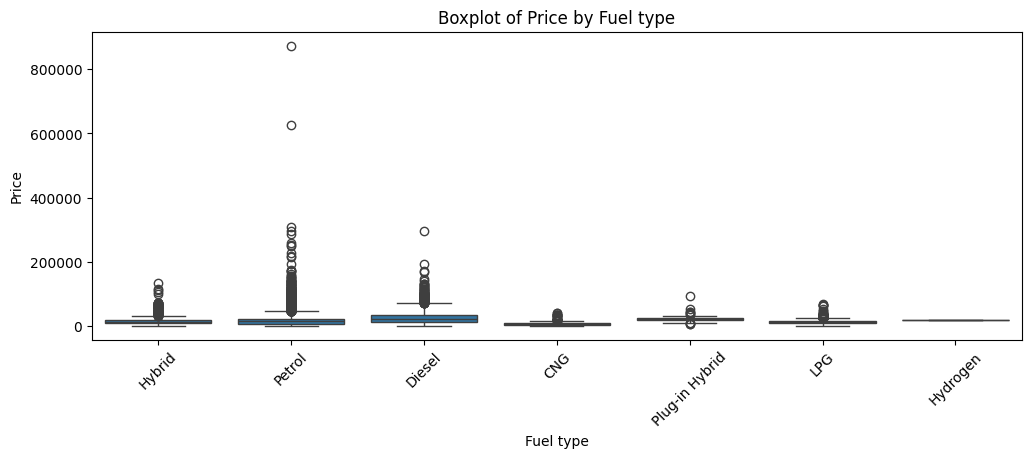

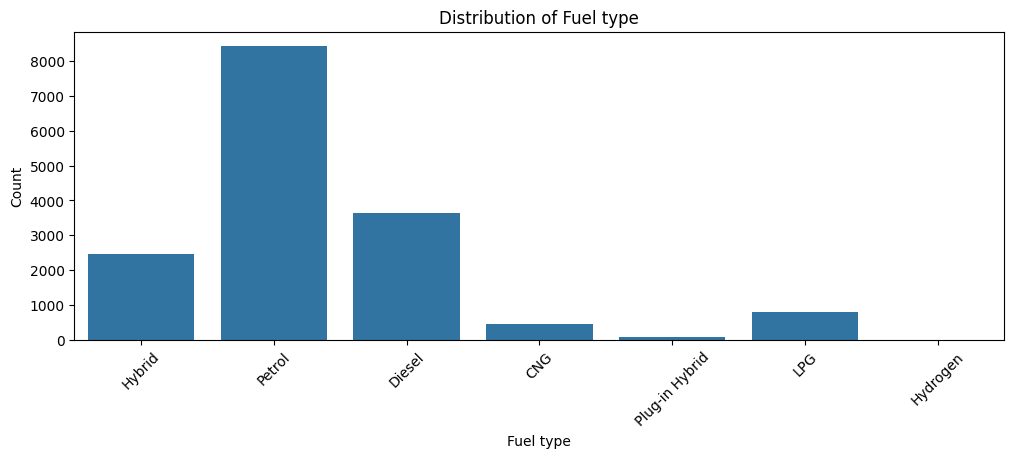

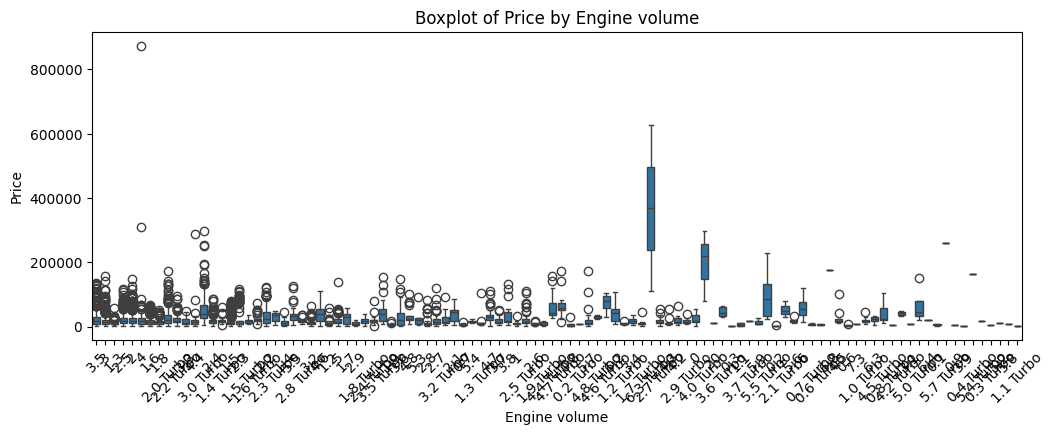

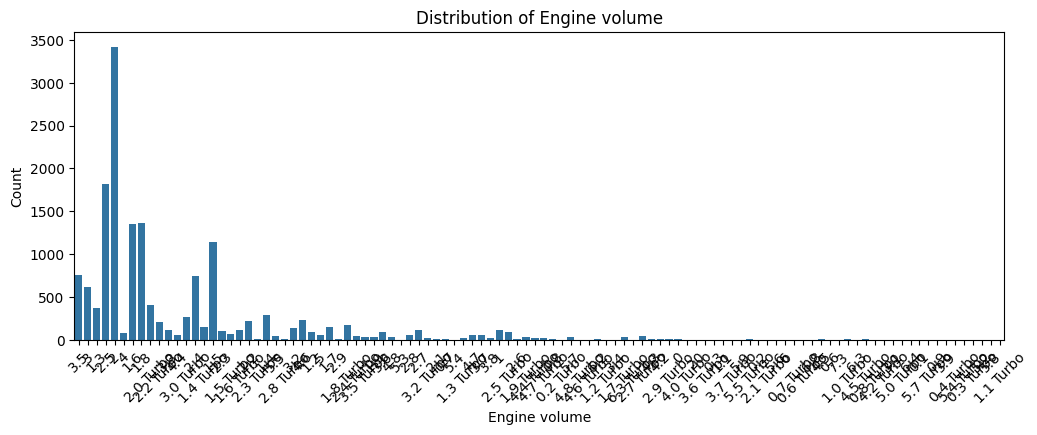

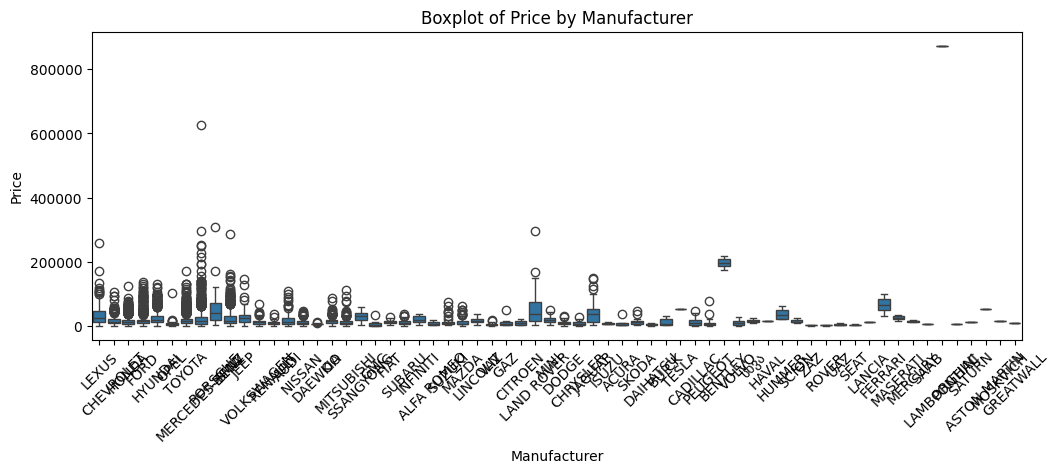

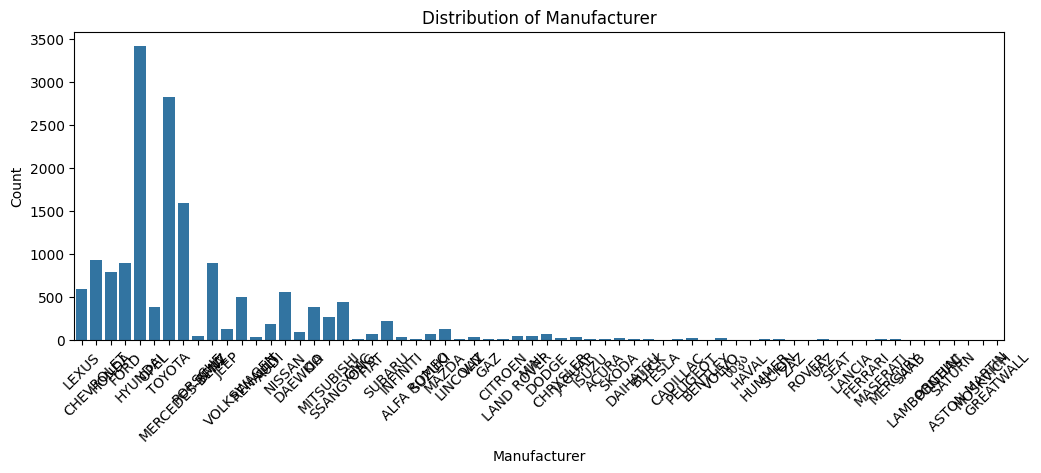

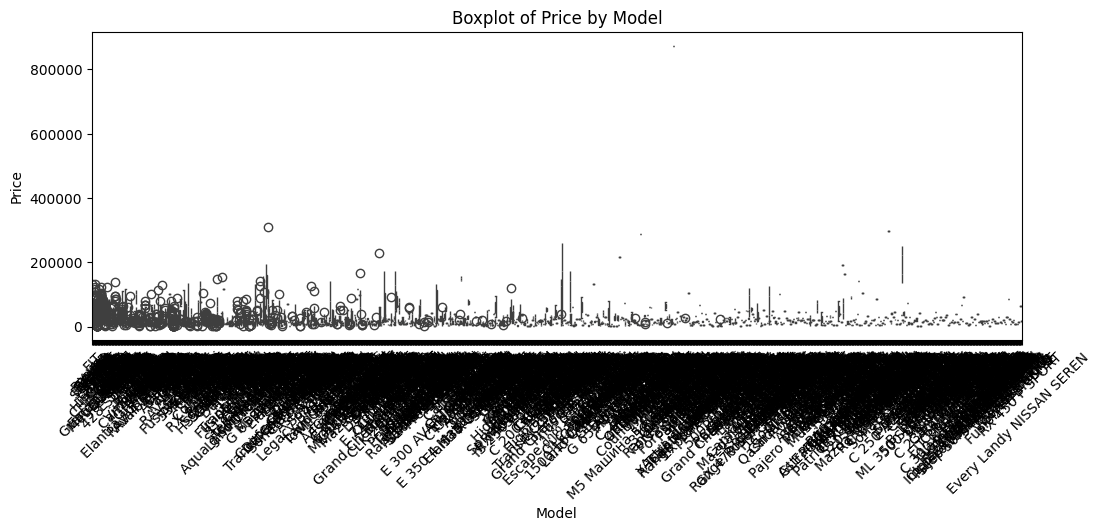

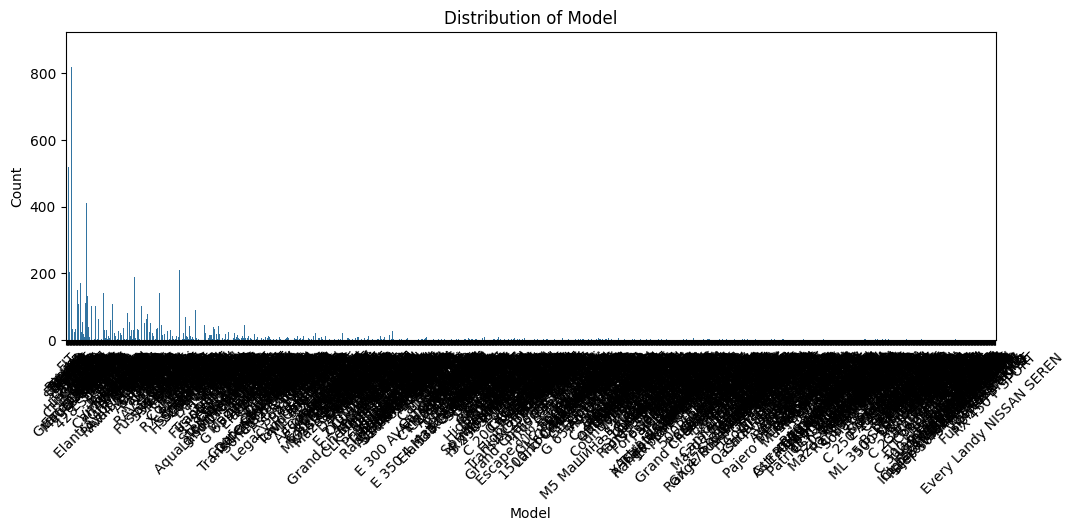

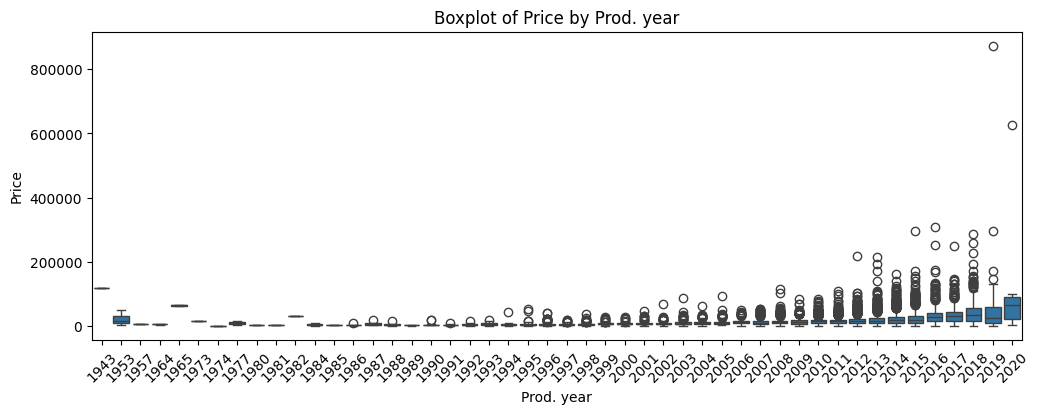

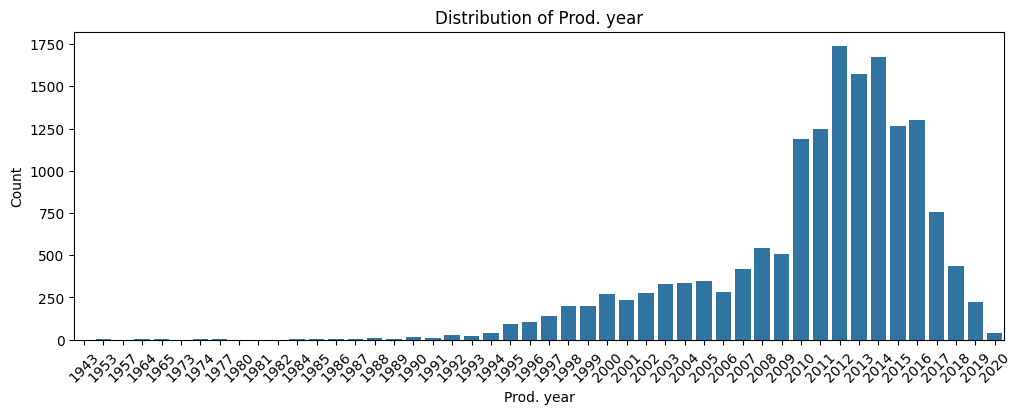

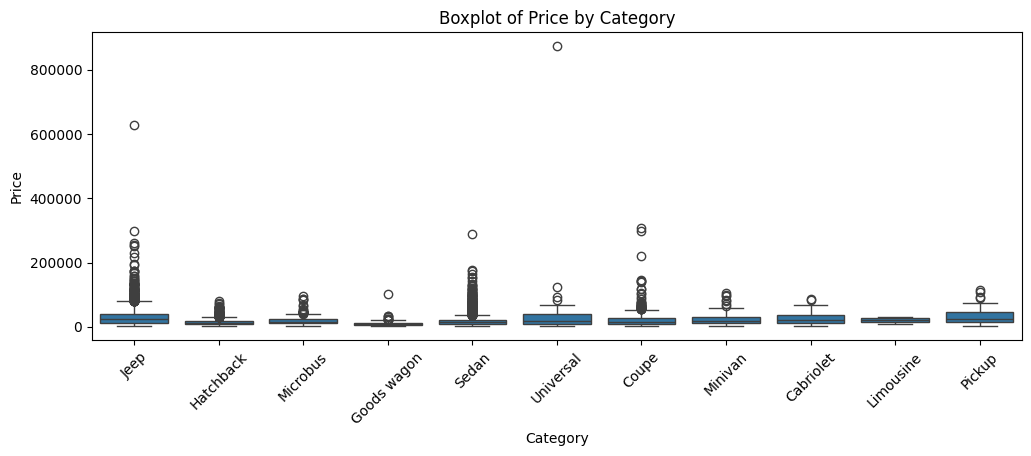

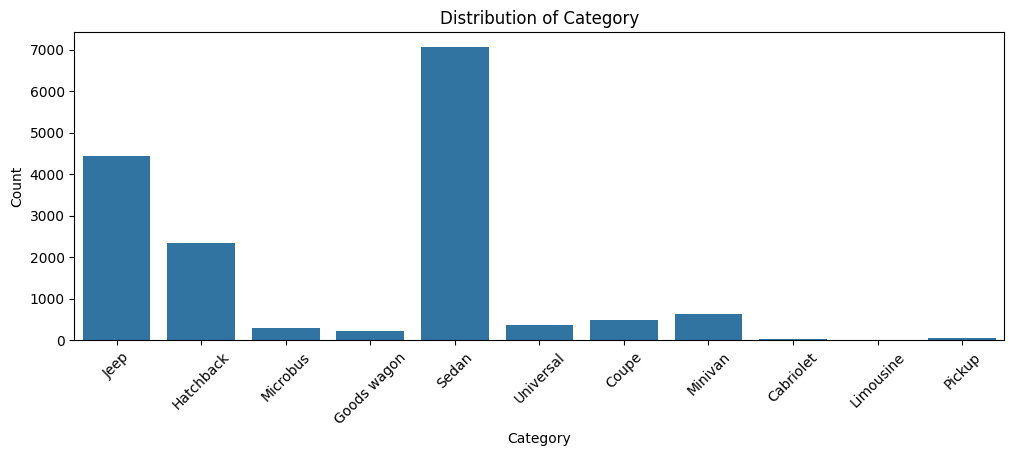

In [ ]:
# Visualize relationship between categorical variables and target variable 'Price' abd distribution of category:
for col in categorical_cols:
    plt.figure(figsize=(12, 4))
    sns.boxplot(x=df[col], y=df['Price'])
    plt.title(f"Boxplot of Price by {col}")
    plt.xlabel(col)
    plt.ylabel("Price")
    plt.xticks(rotation=45)
    plt.show()
    
    # Distribution of categories
    plt.figure(figsize=(12, 4))
    sns.countplot(x=df[col])
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

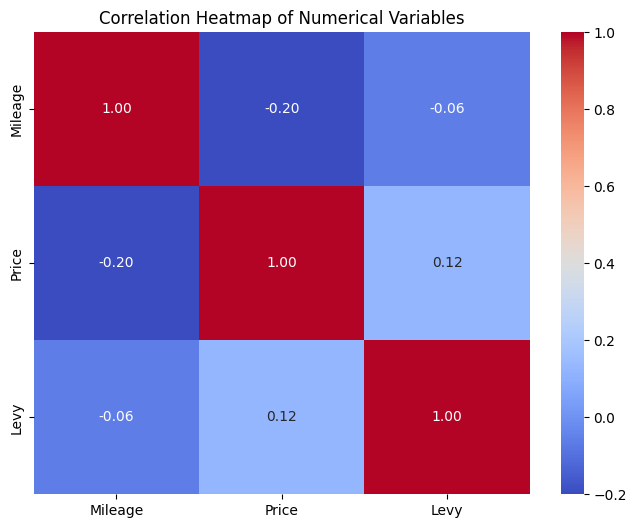

In [40]:
# Checking for heatmap of correlations between numerical variables
numerical_df = df[numerical_cols]
correlation_matrix = numerical_df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()